# NCSU GIS 582: Geospatial Modeling and Analysis

## Introduction to Jupyter Notebooks Assignment B

_Katerina Pascht 1/19/2026_

## Google Colab Setup

Let’s first print system description to know where are we.

In [4]:
!lsb_release -a

No LSB modules are available.
Distributor ID:	Ubuntu
Description:	Ubuntu 22.04.5 LTS
Release:	22.04
Codename:	jammy


At the time of writing this tutorial, Colab has Linux Ubuntu 22.04.4 LTS. So we add the ppa:ubuntugis repository, update and install GRASS. It might take a couple of minutes according to the resources available.

In [5]:
!add-apt-repository -y ppa:ubuntugis/ubuntugis-unstable
!apt update
!apt-get install -y grass-core grass-dev

PPA publishes dbgsym, you may need to include 'main/debug' component
Repository: 'deb https://ppa.launchpadcontent.net/ubuntugis/ubuntugis-unstable/ubuntu/ jammy main'
Description:
Unstable releases of Ubuntu GIS packages. These releases are more bleeding edge and while generally they should work well, they dont receive the same amount of quality assurance as our stable releases do.
More info: https://launchpad.net/~ubuntugis/+archive/ubuntu/ubuntugis-unstable
Adding repository.
Adding deb entry to /etc/apt/sources.list.d/ubuntugis-ubuntu-ubuntugis-unstable-jammy.list
Adding disabled deb-src entry to /etc/apt/sources.list.d/ubuntugis-ubuntu-ubuntugis-unstable-jammy.list
Adding key to /etc/apt/trusted.gpg.d/ubuntugis-ubuntu-ubuntugis-unstable.gpg with fingerprint 2EC86B48E6A9F326623CD22FFF0E7BBEC491C6A1
Get:1 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 https://cloud.r-project.org/bin/linux/ubu

Check that GRASS is installed by asking which version is there.

In [6]:
!grass --version

GRASS GIS 8.4.1
Geographic Resources Analysis Support System (GRASS) is Copyright,
1999-2025 by the GRASS Development Team, and licensed under terms of the
GNU General Public License (GPL) version >=2.

This GRASS GIS 8.4.1 release is coordinated and produced by
the GRASS Development Team with contributions from all over the world.

This program is distributed in the hope that it will be useful, but
WITHOUT ANY WARRANTY; without even the implied warranty of
MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the GNU
General Public License for more details.


Download and unzip the North Carolina basic sample dataset:

In [7]:
!grass --tmp-project XY --exec g.download.project url=https://grass.osgeo.org/sampledata/north_carolina/nc_basic_spm_grass7.tar.gz path=$HOME

Path to the project now </root/nc_basic_spm_grass7>


/root/nc_basic_spm_grass7

/root/nc_basic_spm_grass7/PERMANENT

## Task 1: Import Python Packages and Start GRASS Session

Import the necessary packages and start a GRASS session in the `nc_spm_08_grass7` project and PERMANENT mapset. Confirm the session is working by printing the computational region with `g.region`.

# **Import**

In [8]:
# Import standard Python packages we need
import sys
import subprocess

# Ask GRASS where its Python packages are to be able to run it from the notebook
sys.path.append(
    subprocess.check_output(["grass", "--config", "python_path"], text=True).strip()
)

# Import the GRASS packages
import grass.script as gs
import grass.jupyter as gj

# **Initiate GRASS session in default (PERM) Mapset**

In [9]:
# Start GRASS in default project mapset
session = gj.init("/root/nc_basic_spm_grass7")

# **Confirm session mapset**

In [34]:
#Investigate the raster layers in mapset
gs.list_grouped(type="raster")

{'PERMANENT': ['basins',
  'elevation',
  'elevation_shade',
  'geology',
  'lakes',
  'landuse',
  'soils']}

In [35]:
#Investigate the vector layers in mapset
gs.list_grouped(type="vector")

{'PERMANENT': ['boundary_region',
  'boundary_state',
  'census',
  'elev_points',
  'firestations',
  'geology',
  'geonames',
  'hospitals',
  'points_of_interest',
  'railroads',
  'roadsmajor',
  'schools',
  'streams',
  'streets',
  'zipcodes']}

In [42]:
#Look into the computation region
!g.region -p

projection: 99 (Lambert Conformal Conic)
zone:       0
datum:      nad83
ellipsoid:  a=6378137 es=0.006694380022900787
north:      228500
south:      215000
west:       630000
east:       645000
nsres:      10
ewres:      10
rows:       1350
cols:       1500
cells:      2025000


In [43]:
#Confirm current mapset
gs.read_command("g.mapset", flags="p")


'PERMANENT\n'

## Task 2: Find "Developed" areas close to Schools

You're helping a friend shop for a home. They would like to be within 500m of a school and live in a "developed" landclass. Create a map showing them where they should look. Narrate your workflow.

In [10]:
#import stuff here
!add-apt-repository -y ppa:ubuntugis/ubuntugis-unstable
!apt update
!apt-get install -y grass-core grass-dev
!pip install grass-jupyter ipywidgets

PPA publishes dbgsym, you may need to include 'main/debug' component
Repository: 'deb https://ppa.launchpadcontent.net/ubuntugis/ubuntugis-unstable/ubuntu/ jammy main'
Description:
Unstable releases of Ubuntu GIS packages. These releases are more bleeding edge and while generally they should work well, they dont receive the same amount of quality assurance as our stable releases do.
More info: https://launchpad.net/~ubuntugis/+archive/ubuntu/ubuntugis-unstable
Adding repository.
Found existing deb entry in /etc/apt/sources.list.d/ubuntugis-ubuntu-ubuntugis-unstable-jammy.list
Adding deb entry to /etc/apt/sources.list.d/ubuntugis-ubuntu-ubuntugis-unstable-jammy.list
Found existing deb-src entry in /etc/apt/sources.list.d/ubuntugis-ubuntu-ubuntugis-unstable-jammy.list
Adding disabled deb-src entry to /etc/apt/sources.list.d/ubuntugis-ubuntu-ubuntugis-unstable-jammy.list
Adding key to /etc/apt/trusted.gpg.d/ubuntugis-ubuntu-ubuntugis-unstable.gpg with fingerprint 2EC86B48E6A9F326623CD22FF

In [47]:
# Import standard Python packages we need
import sys
import subprocess

# Ask GRASS where its Python packages are to be able to run it from the notebook
sys.path.append(
    subprocess.check_output(["grass", "--config", "python_path"], text=True).strip()
)

# Import the GRASS packages
import grass.script as gs
import grass.jupyter as gj
from grass.jupyter import init
from grass import script

**Layers of interest:**
* landuse ... this layer will isolate for the "developed" landclass areas
* schools.wake ... this layer we buffer for 500 m
* potentially a boundary layer to make it look nice?

**Data Location:**
* The landclass layer currently lives within the PERMANENT mapset 'landuse96_28m' or 'landclass96'
**/root/nc_basic_spm_grass7/PERMANENT/cell/landuse**
* The Wake Co schools layer lives within the PERMANENT mapset 'schools_wake' or 'schools'
**/root/nc_basic_spm_grass7/PERMANENT/vector/schools**
* The computational region will be definied by the landuse extent/resolution


In [48]:
# Start GRASS in default project mapset
session = gj.init("/root/nc_basic_spm_grass7")

In [13]:
# Set computational region to the extent of the landuse raster layer
!g.region raster=landuse -p

projection: 99 (Lambert Conformal Conic)
zone:       0
datum:      nad83
ellipsoid:  a=6378137 es=0.006694380022900787
north:      228527.25
south:      215018.25
west:       629980
east:       644971
nsres:      28.5
ewres:      28.5
rows:       474
cols:       526
cells:      249324


*Before adding the landuse raster layer, determine if this raster is appropriate for the situation*

In [14]:
# Investigate the metadata for the most obvious raster layer 'landuse'
# Consider the resolution size, extent, and number of categories
!r.info map=landuse

 +----------------------------------------------------------------------------+
 | Map:      landuse                        Date: Fri Oct 17 13:39:34 2008    |
 | Mapset:   PERMANENT                      Login of Creator: hmitaso         |
 | Project:  nc_basic_spm_grass7                                              |
 | DataBase: /root                                                            |
 | Title:    Land use                                                         |
 | Timestamp: none                                                            |
 |----------------------------------------------------------------------------|
 |                                                                            |
 |   Type of Map:  raster               Number of Categories: 7               |
 |   Data Type:    CELL                 Semantic label: (none)                |
 |   Rows:         474                                                        |
 |   Columns:      526                  

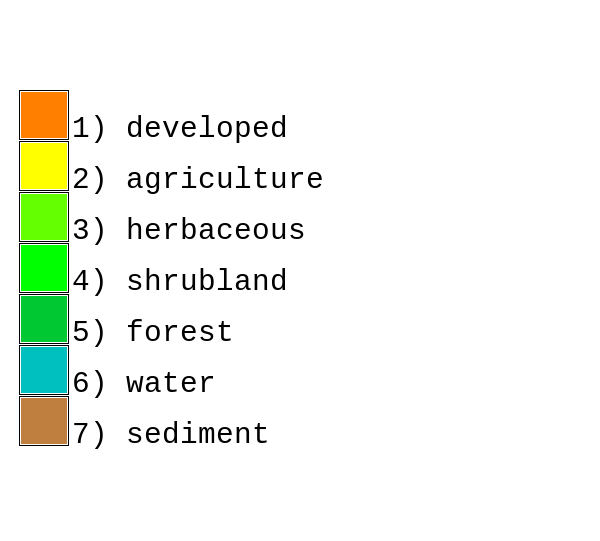

In [15]:
# Add the landuse legend...the raster layer does not have to be on map display for the legend to generate...
m = gj.Map()
m.d_legend(raster="landuse")
m.show()

*After evaluating the legend, landuse does suit our needs because it has a simpler classification of 7 categories and the legend confirms the presence of "developed" areas*

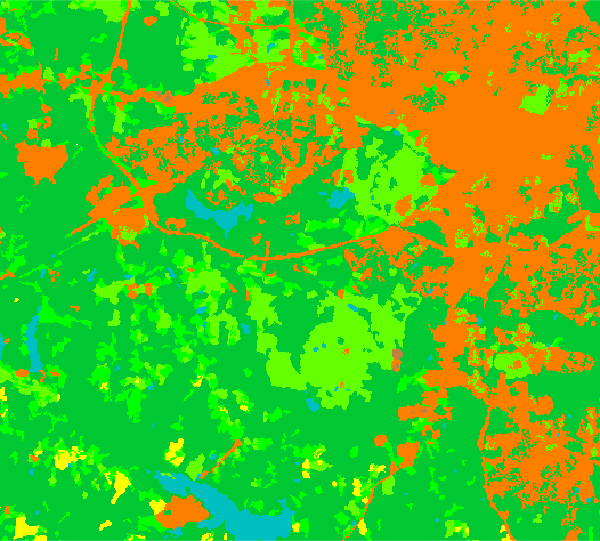

In [16]:
# Add raster 'landuse' map layer first
w = gj.Map()
w.d_rast(map="landuse")
w.show()

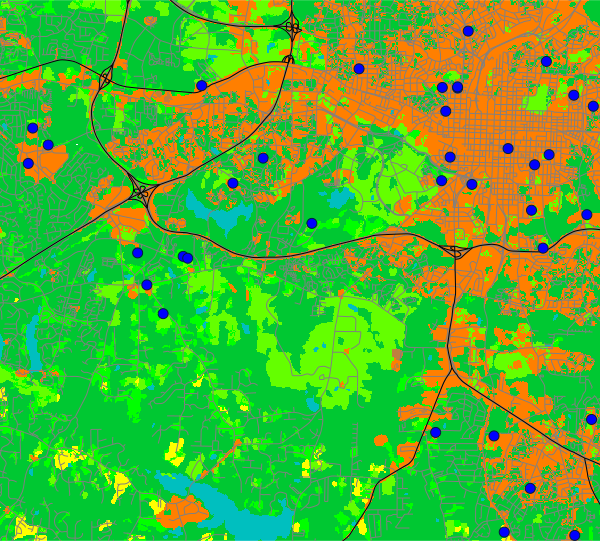

In [17]:
# Add vector 'streets,'roadsmajor', and 'schools' map layers, in that order
w.d_vect(map="streets", color="grey", width="1")
w.d_vect(map="roadsmajor", color="black", width="1")
w.d_vect(map="schools", icon="basic/circle", size="10", fill_color="blue")
w.show()

In [18]:
# Confirm computational region -p ... it should still be the landuse raster extent
!g.region -p

projection: 99 (Lambert Conformal Conic)
zone:       0
datum:      nad83
ellipsoid:  a=6378137 es=0.006694380022900787
north:      228527.25
south:      215018.25
west:       629980
east:       644971
nsres:      28.5
ewres:      28.5
rows:       474
cols:       526
cells:      249324


In [19]:
#Confirm map units of school vector layer
!v.info map=schools

 +----------------------------------------------------------------------------+
 | Name:            schools                                                   |
 | Mapset:          PERMANENT                                                 |
 | Project:         nc_basic_spm_grass7                                       |
 | Database:        /root                                                     |
 | Title:           Wake County schools (points map)                          |
 | Map scale:       1:1                                                       |
 | Name of creator: helena                                                    |
 | Organization:    NC OneMap                                                 |
 | Source date:     Tue Nov  7 19:34:09 2006                                  |
 | Timestamp (first layer): none                                              |
 |----------------------------------------------------------------------------|
 | Map format:      native              

*Based on the legend, developed =1. Need to figure out how to either pull only those areas out or do a spatial query for schools w/in that landclass value and then buffer? However, because of the buffer there may be a way to knock both these criterias in one fell swoop??*

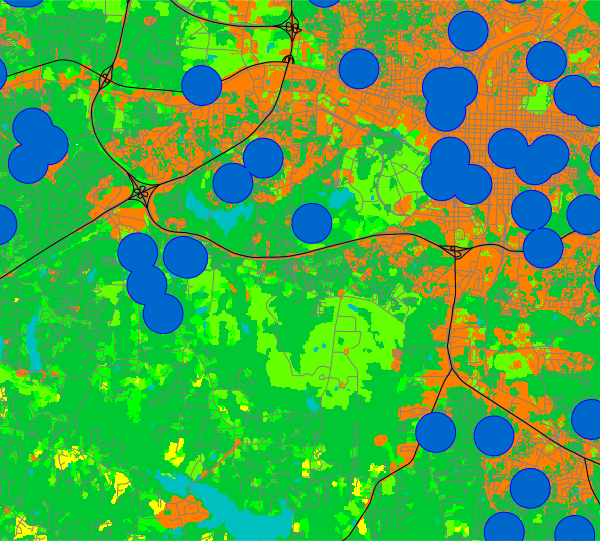

In [20]:
# Buffer
# Assume 'input_vector' is your vector map, 'buffer_dist' is distance (e.g., 500 meters)
gs.run_command("v.buffer", input='schools', output='buffer_output', distance=500)
w.d_vect(map="buffer_output", color="blue")
w.show()


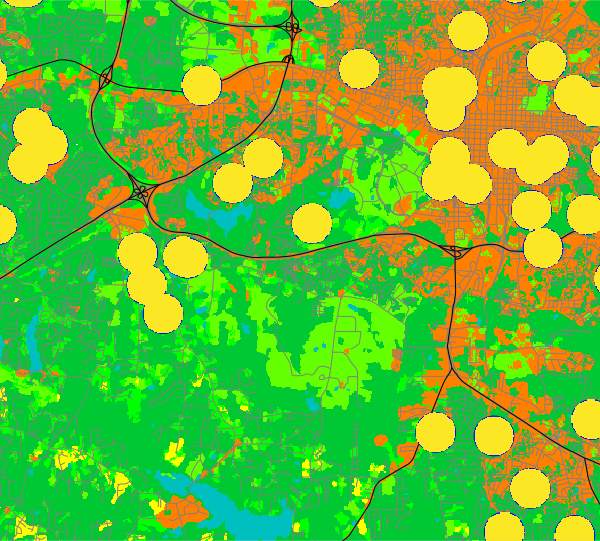

In [25]:
# Rasterize the buffer output to match the landuse resolution
# v.to.rast input=my_buffer output=buffer_raster type=area use=cat (if using feature IDs) or use=1 for binary.
gs.run_command("v.to.rast", input='buffer_output', output='scoolbuffconv', use="value") #this worked in Grass
w.d_rast(map="scoolbuffconv")
w.show()


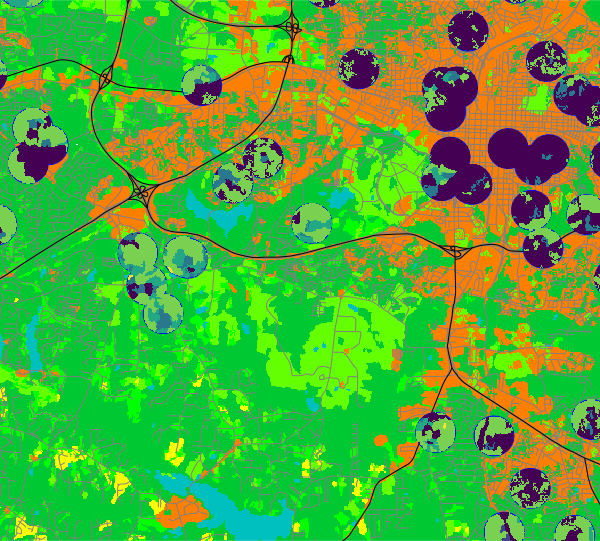

In [36]:
# Then use r.mapcalc to either intersect or overlap mask?
# r.mapcalc "intersect_raster = my_raster * buffer_raster"
# r.mapcalc "overlap_mask = (buffer_raster == 1) & (my_raster > 0)"
#r.stats input=my_raster output=overlap_stats_csv cover=overlap_mask

gs.run_command("r.mapcalc", expression="developedbuff = landuse * scoolbuffconv")
w.d_rast(map="developedbuff")
w.show()





In [35]:
!r.info map=developedbuff

 +----------------------------------------------------------------------------+
 | Map:      developedbuff                  Date: Thu Jan 22 03:09:23 2026    |
 | Mapset:   PERMANENT                      Login of Creator: root            |
 | Project:  nc_basic_spm_grass7                                              |
 | DataBase: /root                                                            |
 | Title:                                                                     |
 | Timestamp: none                                                            |
 |----------------------------------------------------------------------------|
 |                                                                            |
 |   Type of Map:  raster               Number of Categories: 0               |
 |   Data Type:    CELL                 Semantic label: (none)                |
 |   Rows:         474                                                        |
 |   Columns:      526                  

In [52]:
#Confirm comp region
!g.region raster=landuse -p

projection: 99 (Lambert Conformal Conic)
zone:       0
datum:      nad83
ellipsoid:  a=6378137 es=0.006694380022900787
north:      228527.25
south:      215018.25
west:       629980
east:       644971
nsres:      28.5
ewres:      28.5
rows:       474
cols:       526
cells:      249324


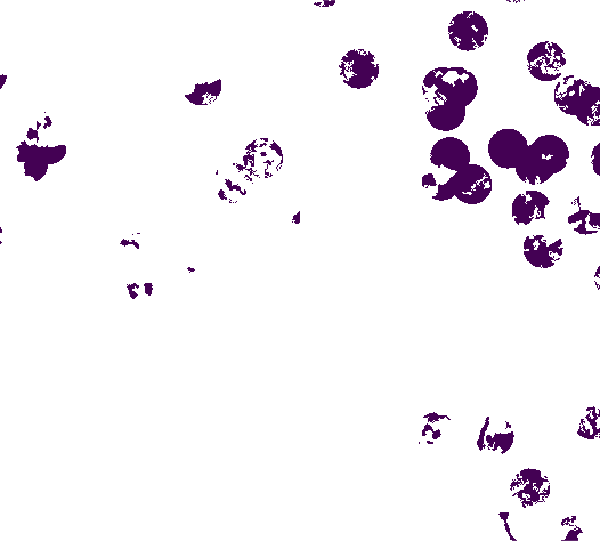

In [68]:
# Creat a new map - B
B = gj.Map()
B.d_rast(map="developedbuff", values="1")
B.show()

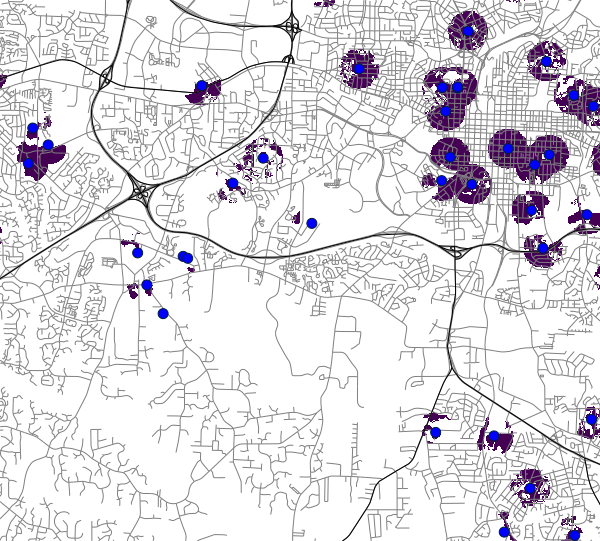

In [69]:
# Add vector 'streets,'roadsmajor', 'developedbuff', and 'schools' map layers, in that order
B.d_vect(map="streets", color="grey", width="1")
B.d_vect(map="roadsmajor", color="black", width="1")
B.d_vect(map="schools", icon="basic/circle", size="10", fill_color="blue")
B.show()

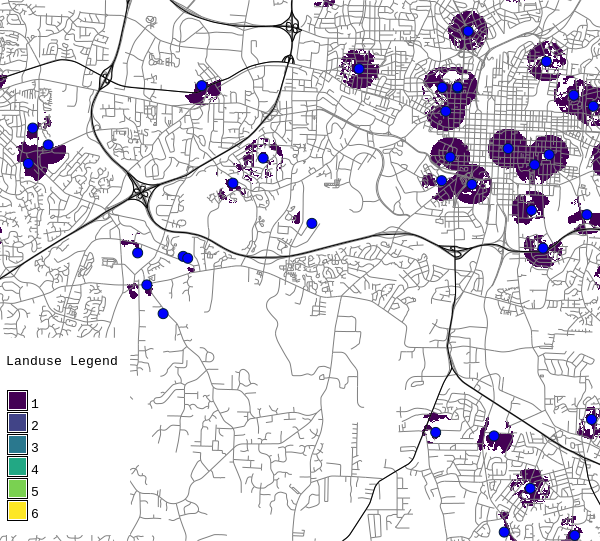

In [70]:
#Add map elements
#Q.d_legend(raster="developedbuff")
B.d_legend(
    raster="developedbuff",
    at=(1, 30 , 1, 8), # Sets the legend box location
    title="Landuse Legend",
    border_color="none", # Or "black" for a border
    flags="bt" # 'b' for border, 't' for title
)
B.show()

The final product is a map display of streets and major roads in SW Raleigh NC. Most importantly it displays "developed" areas (dark purple, value = 1) within 500 meters from Wake County schools. If you refer to the 'landuse' legend generated in the very beginning, the value '1' corresponds to "developed" areas, and the final raster buffer result seen here was extracted from the original landuse raster layer.